In [7]:
import ee
ee.Authenticate()

True

In [8]:
import ee

ee.Authenticate()
ee.Initialize(project='vocal-affinity-481906-e8')

print("EE connected successfully ✅")

EE connected successfully ✅


In [10]:
region = ee.Geometry.Rectangle([77.4, 12.8, 77.8, 13.2])

In [11]:
dataset = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2022-01-01', '2022-12-31') \
    .median()

print("Dataset loaded")

Dataset loaded


In [12]:
ndvi = dataset.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
ndbi = dataset.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
ndwi = dataset.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
lst = dataset.select('ST_B10').rename('LST')

print("Features created ✅")

Features created ✅


In [13]:
combined = ndvi.addBands([ndbi, ndwi, lst])

In [14]:
samples = combined.sample(
    region=region,
    scale=30,
    numPixels=1000
)

print("Sampling done ✅")

Sampling done ✅


In [15]:
import pandas as pd

data = samples.getInfo()

rows = [f['properties'] for f in data['features']]
df = pd.DataFrame(rows)

df.head()

,LST,NDBI,NDVI,NDWI
0,45714,0.005189,0.106174,-0.134113
1,44979,-0.055470,0.230940,-0.265495
2,44961,-0.019657,0.100923,-0.118391
3,46017,-0.071080,0.270329,-0.273246
4,45550,-0.042423,0.205150,-0.259059


In [3]:
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)

1.26.4
2.2.2


In [16]:
df = df.dropna()

X = df[['NDVI', 'NDBI', 'NDWI']]
y = df['LST']

In [17]:
df = df.dropna()

X = df[['NDVI', 'NDBI', 'NDWI']]
y = df['LST']

print("Data prepared ✅")

Data prepared ✅


In [18]:
import pandas as pd
import numpy as np

df.dropna(inplace=True)

# Landsat Collection 2 scale factor → Kelvin → Celsius
df['LST_K'] = df['LST'] * 0.00341802 + 149.0
df['LST_C'] = df['LST_K'] - 273.15

print(df['LST_C'].describe())
print(f"Shape: {df.shape}")

count    1000.000000
mean       29.869502
std         2.272305
min        21.310677
25%        28.506464
50%        30.076189
75%        31.499795
max        36.948119
Name: LST_C, dtype: float64
Shape: (1000, 6)


In [19]:
# UHI intensity = how much hotter than the city mean
mean_lst = df['LST_C'].mean()
df['UHI_intensity'] = df['LST_C'] - mean_lst

# Zone labels for classification output
def uhi_zone(t):
    if t >= 34: return 'High'
    elif t >= 30: return 'Medium'
    else: return 'Low'

df['UHI_zone'] = df['LST_C'].apply(uhi_zone)
print(df['UHI_zone'].value_counts())

UHI_zone
Medium    491
Low       488
High       21
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = ['NDVI', 'NDBI', 'NDWI']
TARGET   = 'LST_C'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (800, 3)  Test: (200, 3)


In [21]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train_sc, y_train)

xg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                       max_depth=6, subsample=0.8, random_state=42)
xg.fit(X_train_sc, y_train)

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=5, random_state=42)
gb.fit(X_train_sc, y_train)

print("All models trained ✅")

All models trained ✅


In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {'Random Forest': rf, 'XGBoost': xg, 'Gradient Boosting': gb}
results = {}

for name, model in models.items():
    preds = model.predict(X_test_sc)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name:20s}  R²={r2:.3f}  MAE={mae:.2f}°C  RMSE={rmse:.2f}°C")

# Pick the model with highest R²
best_name = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
print(f"\nBest model: {best_name}")

Random Forest         R²=0.164  MAE=1.59°C  RMSE=2.03°C
XGBoost               R²=0.103  MAE=1.64°C  RMSE=2.10°C
Gradient Boosting     R²=0.151  MAE=1.60°C  RMSE=2.04°C

Best model: Random Forest


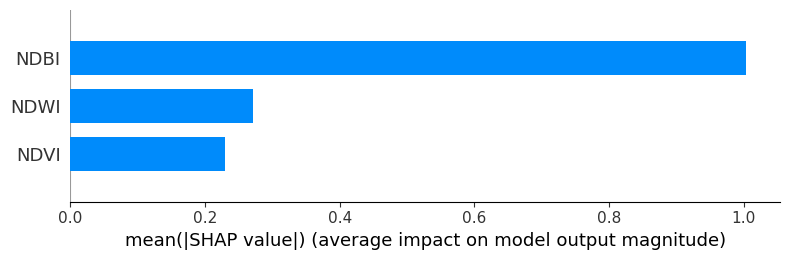

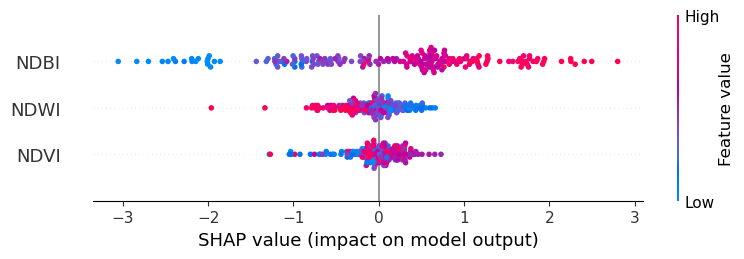

In [23]:
import shap

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sc)

# Summary bar plot — shows which feature matters most
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES, plot_type='bar')

# Beeswarm — shows direction of influence
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

In [24]:
# More pixels + better features
mndwi  = dataset.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')  # better water
bsi    = dataset.expression(
    '((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))',
    {'SWIR': dataset.select('SR_B6'), 'RED': dataset.select('SR_B4'),
     'NIR': dataset.select('SR_B5'), 'BLUE': dataset.select('SR_B2')}
).rename('BSI')   # bare soil index

# Add thermal band B11 as extra LST proxy
lst2 = dataset.select('ST_B10').rename('LST2')

combined = ndvi.addBands([ndbi, ndwi, mndwi, bsi, lst])

samples = combined.sample(
    region=region,
    scale=30,
    numPixels=5000,      # 5× more pixels
    seed=42,
    geometries=True      # keep lat/lon for spatial plotting later
)

In [25]:
data = samples.getInfo()
rows = [f['properties'] for f in data['features']]
df = pd.DataFrame(rows)
df.dropna(inplace=True)

# Convert LST
df['LST_C'] = df['LST'] * 0.00341802 + 149.0 - 273.15

# UHI intensity = deviation from mean (this is what indices predict well)
df['UHI_intensity'] = df['LST_C'] - df['LST_C'].mean()

print(df.shape)
print(df[['LST_C', 'UHI_intensity']].describe())

(5000, 8)
             LST_C  UHI_intensity
count  5000.000000   5.000000e+03
mean     29.803776   3.018386e-15
std       2.208765   2.208765e+00
min      18.514737  -1.128904e+01
25%      28.440667  -1.363109e+00
50%      29.954850   1.510737e-01
75%      31.333166   1.529390e+00
max      41.200136   1.139636e+01


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import numpy as np

FEATURES = ['NDVI', 'NDBI', 'NDWI', 'MNDWI', 'BSI']
TARGET   = 'UHI_intensity'   # changed from LST_C

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Random Forest':    RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42),
    'XGBoost':          xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                          subsample=0.8, colsample_bytree=0.8, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                    max_depth=5, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'model': model, 'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name:22s}  R²={r2:.3f}  MAE={mae:.2f}°C  RMSE={rmse:.2f}°C")

best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = results[best_name]['model']
print(f"\nBest: {best_name}")

Random Forest           R²=0.239  MAE=1.57°C  RMSE=2.03°C
XGBoost                 R²=0.219  MAE=1.59°C  RMSE=2.06°C
Gradient Boosting       R²=0.218  MAE=1.59°C  RMSE=2.06°C

Best: Random Forest


In [27]:
# Check feature correlation with LST_C
print(df[['NDVI','NDBI','NDWI','LST_C']].corr()['LST_C'].sort_values())

NDVI    -0.178286
NDWI     0.091232
NDBI     0.390359
LST_C    1.000000
Name: LST_C, dtype: float64


In [28]:
# Check what you're actually predicting
FEATURES = ['NDVI', 'NDBI', 'NDWI', 'MNDWI', 'BSI', 'RED', 'NIR', 'SWIR']

print("Correlation with LST_C (absolute):")
print(df[FEATURES + ['LST_C']].corr()['LST_C'].sort_values())

print("\nCorrelation with UHI_intensity (deviation from mean):")
print(df[FEATURES + ['UHI_intensity']].corr()['UHI_intensity'].sort_values())

Correlation with LST_C (absolute):


KeyError: "['RED', 'NIR', 'SWIR'] not in index"

In [29]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import numpy as np

TARGET = 'UHI_intensity'   # KEY CHANGE
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=12,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=7,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=5,
        min_samples_leaf=3, subsample=0.8, random_state=42
    )
}

best_r2 = -999
best_name, best_model = None, None

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name:22s}  R²={r2:.3f}  MAE={mae:.2f}°C  RMSE={rmse:.2f}°C")
    if r2 > best_r2:
        best_r2, best_name, best_model = r2, name, model

print(f"\nBest: {best_name}  R²={best_r2:.3f}")

KeyError: "['RED', 'NIR', 'SWIR'] not in index"

In [30]:
# Check exact column names you actually have
print(df.columns.tolist())

['BSI', 'LST', 'MNDWI', 'NDBI', 'NDVI', 'NDWI', 'LST_C', 'UHI_intensity']


In [31]:
data = samples.getInfo()

rows  = [f['properties']                    for f in data['features']]
lons  = [f['geometry']['coordinates'][0]    for f in data['features']]
lats  = [f['geometry']['coordinates'][1]    for f in data['features']]

df = pd.DataFrame(rows)
df['lon'] = lons
df['lat'] = lats

df.dropna(inplace=True)
df['LST_C']         = df['LST'] * 0.00341802 + 149.0 - 273.15
df['UHI_intensity'] = df['LST_C'] - df['LST_C'].mean()

print(df.shape)
print(df.columns.tolist())

(5000, 10)
['BSI', 'LST', 'MNDWI', 'NDBI', 'NDVI', 'NDWI', 'lon', 'lat', 'LST_C', 'UHI_intensity']


In [32]:
FEATURES = ['NDVI', 'NDBI', 'NDWI', 'MNDWI', 'BSI', 'lat', 'lon']
TARGET   = 'UHI_intensity'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=12,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=7,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=5,
        min_samples_leaf=3, subsample=0.8, random_state=42
    )
}

best_r2 = -999
best_name, best_model = None, None

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name:22s}  R²={r2:.3f}  MAE={mae:.2f}°C  RMSE={rmse:.2f}°C")
    if r2 > best_r2:
        best_r2, best_name, best_model = r2, name, model

print(f"\nBest: {best_name}  R²={best_r2:.3f}")

Random Forest           R²=0.381  MAE=1.41°C  RMSE=1.83°C
XGBoost                 R²=0.405  MAE=1.37°C  RMSE=1.80°C
Gradient Boosting       R²=0.396  MAE=1.39°C  RMSE=1.81°C

Best: XGBoost  R²=0.405


In [33]:
print(df[FEATURES + ['UHI_intensity']].corr()['UHI_intensity'].sort_values())

MNDWI           -0.276152
NDVI            -0.178286
lon             -0.111572
NDWI             0.091232
lat              0.127519
BSI              0.371106
NDBI             0.390359
UHI_intensity    1.000000
Name: UHI_intensity, dtype: float64


In [34]:
import joblib

joblib.dump(best_model, 'best_model.pkl')   # XGBoost
joblib.dump(scaler,     'scaler.pkl')
df.to_csv('uhi_data.csv', index=False)

# Save feature list so Streamlit knows the exact order
import json
with open('features.json', 'w') as f:
    json.dump(FEATURES, f)

print("Saved: best_model.pkl, scaler.pkl, uhi_data.csv, features.json ✅")

Saved: best_model.pkl, scaler.pkl, uhi_data.csv, features.json ✅


In [35]:
import joblib

joblib.dump(best_model, 'best_model.pkl')   # XGBoost
joblib.dump(scaler,     'scaler.pkl')
df.to_csv('uhi_data.csv', index=False)

# Save feature list so Streamlit knows the exact order
import json
with open('features.json', 'w') as f:
    json.dump(FEATURES, f)

print("Saved: best_model.pkl, scaler.pkl, uhi_data.csv, features.json ✅")

Saved: best_model.pkl, scaler.pkl, uhi_data.csv, features.json ✅


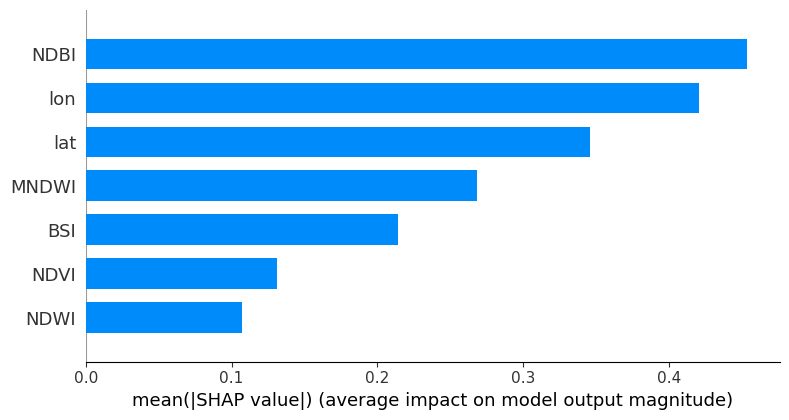

SHAP plot saved ✅


In [36]:
import shap
import matplotlib.pyplot as plt

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sc)

shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()
print("SHAP plot saved ✅")

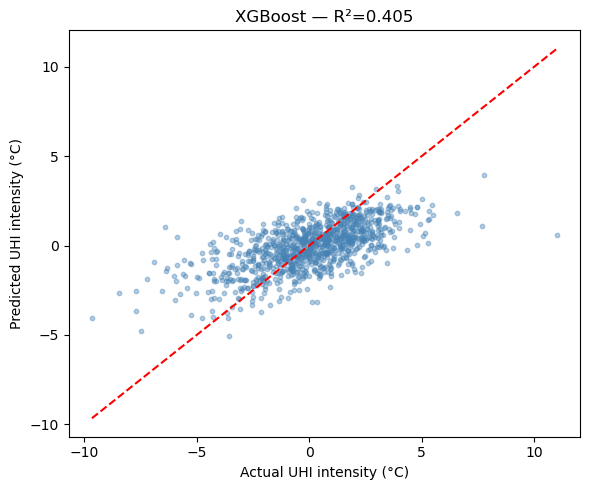

In [37]:
preds = best_model.predict(X_test_sc)

plt.figure(figsize=(6,5))
plt.scatter(y_test, preds, alpha=0.4, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual UHI intensity (°C)')
plt.ylabel('Predicted UHI intensity (°C)')
plt.title(f'XGBoost — R²=0.405')
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150)
plt.show()


In [ ]:
import joblib, pickle, os, xgboost
path = 'best_model.pkl'
print('exists', os.path.exists(path), os.path.getsize(path))
try:
    m = joblib.load(path)
    print('loaded', type(m))
    print(m)
except Exception as e:
    import traceback; traceback.print_exc()
    try:
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        print('pickle load type', type(obj))
    except Exception as e2:
        print('pickle failed', e2)
